In [10]:
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle

print("✅ All imports successful!")

✅ All imports successful!


In [19]:
SAVE_PATH         = "MP_Data"
SELECTED_GESTURES = ['drink', 'go', 'help', 'yes', 'no']

frames_list = []  # Individual frames (not sequences)
labels_list = []  # Label for each frame

print("📂 Loading and extracting frames...\n")

for gesture in SELECTED_GESTURES:
    gesture_path = os.path.join(SAVE_PATH, gesture)
    files        = os.listdir(gesture_path)

    for file in files:
        filepath = os.path.join(gesture_path, file)
        sequence = np.load(filepath)
        # sequence shape: (30, 64, 64, 1)

        for frame in sequence:
            frames_list.append(frame)
            labels_list.append(gesture)
            # 💡 Instead of keeping 30 frames together as one sample,
            #    we treat EACH frame as its own independent training image
            #    with the gesture label attached to it
            #    30 frames × 1 video = 30 individual training images!

    print(f"  ✅ {gesture:10s} → {len(files)} videos × 30 frames "
          f"= {len(files)*30} training images")

X = np.array(frames_list)  # Shape: (total_frames, 64, 64, 1)
print(f"\n📐 X shape: {X.shape}")
print(f"📝 Total frame samples: {len(labels_list)}")

# Convert grayscale (64,64,1) → RGB (64,64,3) for MobileNetV2
X_rgb = np.repeat(X, 3, axis=-1)
# 💡 MobileNetV2 needs 3 channels — we repeat the grayscale channel 3 times
print(f"📐 X_rgb shape: {X_rgb.shape}  ← ready for MobileNetV2")

📂 Loading and extracting frames...

  ✅ drink      → 35 videos × 30 frames = 1050 training images
  ✅ go         → 35 videos × 30 frames = 1050 training images
  ✅ help       → 34 videos × 30 frames = 1020 training images
  ✅ yes        → 32 videos × 30 frames = 960 training images
  ✅ no         → 31 videos × 30 frames = 930 training images

📐 X shape: (5010, 64, 64, 1)
📝 Total frame samples: 5010
📐 X_rgb shape: (5010, 64, 64, 3)  ← ready for MobileNetV2


In [20]:
le        = LabelEncoder()
y_encoded = le.fit_transform(labels_list)
y         = to_categorical(y_encoded)

print(f"📐 y shape: {y.shape}")
print(f"\n🏷️  Label mapping:")
for i, name in enumerate(le.classes_):
    print(f"   {i} → {name}")

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print("\n✅ Label encoder saved!")

📐 y shape: (5010, 5)

🏷️  Label mapping:
   0 → drink
   1 → go
   2 → help
   3 → no
   4 → yes

✅ Label encoder saved!


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_rgb, y,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
    # 💡 stratify ensures each gesture class is fairly represented
    #    in both train and test sets — very important with small datasets
)

print(f"📊 Data Split:")
print(f"   Training frames : {X_train.shape[0]}")
print(f"   Testing  frames : {X_test.shape[0]}")
print(f"   Frame shape     : {X_train.shape[1:]}")
print(f"   Classes         : {y_train.shape[1]}")

📊 Data Split:
   Training frames : 4008
   Testing  frames : 1002
   Frame shape     : (64, 64, 3)
   Classes         : 5


In [22]:
NUM_CLASSES = 5
IMG_SIZE    = 64

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False
# 💡 Freeze pretrained weights — we only train our new top layers
#    MobileNetV2 already knows how to detect shapes and textures
#    We just need it to learn OUR specific gesture patterns on top

# Add our classification head on top
x      = base_model.output
x      = GlobalAveragePooling2D()(x)
# 💡 Squashes the spatial feature maps into a single vector
x      = Dropout(0.3)(x)
x      = Dense(128, activation='relu')(x)
# 💡 128 neurons to combine the MobileNetV2 features
x      = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)
# 💡 5 output neurons — one probability per gesture class

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    # 💡 Lower learning rate (0.0001 vs 0.001) — takes smaller steps
    #    Important when using pretrained models — we don't want to
    #    accidentally overwrite the good features MobileNetV2 learned
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Count trainable vs frozen parameters
trainable     = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable = sum([tf.size(w).numpy() for w in model.non_trainable_weights])
print(f"🔒 Frozen parameters    : {non_trainable:,}  (MobileNetV2 pretrained)")
print(f"🔓 Trainable parameters : {trainable:,}  (our new layers only)")

C:\Users\lenovo\AppData\Local\Temp\ipykernel_24880\3080052791.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


🔒 Frozen parameters    : 2,257,984  (MobileNetV2 pretrained)
🔓 Trainable parameters : 164,613  (our new layers only)


In [23]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model_v2.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("🚀 Training frame-based classifier...\n")

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    # 💡 batch_size=32 works well here since we now have
    #    ~1200 training frames instead of just 53 sequences
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint]
)

print(f"\n✅ Training complete!")
print(f"🏆 Best val accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

🚀 Training frame-based classifier...

Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.2905 - loss: 1.8156
Epoch 1: val_accuracy improved from None to 0.71756, saving model to best_model_v2.keras

Epoch 1: finished saving model to best_model_v2.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - accuracy: 0.3925 - loss: 1.5358 - val_accuracy: 0.7176 - val_loss: 0.9194
Epoch 2/50
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6004 - loss: 1.0695
Epoch 2: val_accuracy improved from 0.71756 to 0.81836, saving model to best_model_v2.keras

Epoch 2: finished saving model to best_model_v2.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.6382 - loss: 0.9737 - val_accuracy: 0.8184 - val_loss: 0.6293
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7372 - loss: 0.7623
Epoch 3: val_accuracy improved from 0.81836 to 0.86627, saving model to best_model_v2.keras

Epoch 3: finished saving model to best_model_v2.keras
126/126 ━━━━━━━━━━━━━━━

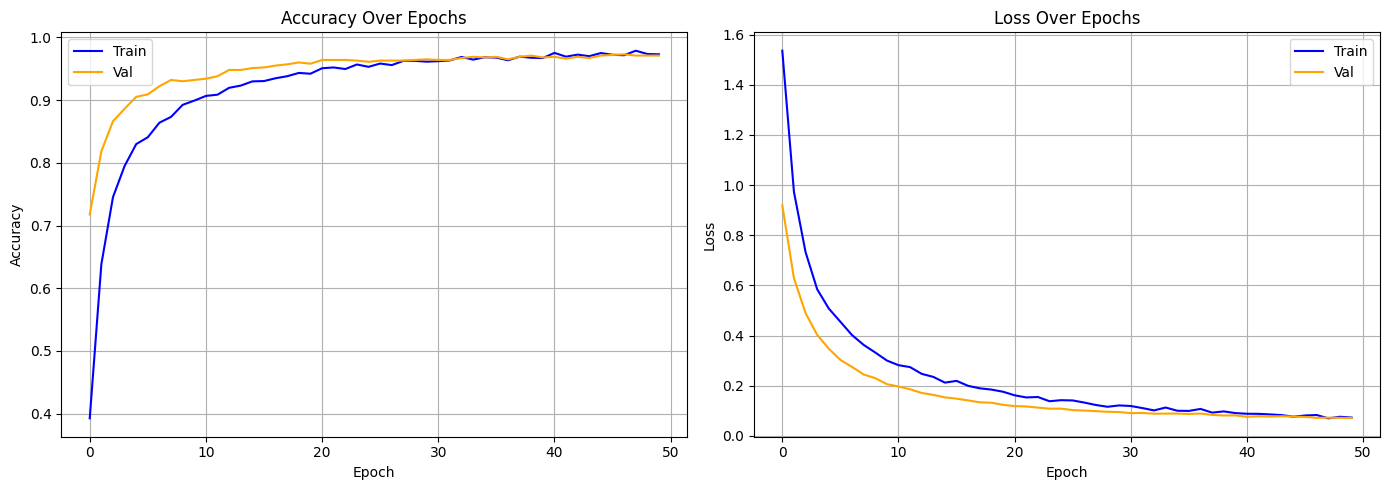

🏆 Best Val Accuracy: 97.31%


In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val',   color='orange')
ax1.set_title('Accuracy Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'],     label='Train', color='blue')
ax2.plot(history.history['val_loss'], label='Val',   color='orange')
ax2.set_title('Loss Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()
print(f"🏆 Best Val Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

In [25]:
# Reload original sequences for voting test
SEQUENCE_LENGTH = 30
sequences_test  = []
labels_test     = []

for gesture in SELECTED_GESTURES:
    gesture_path = os.path.join(SAVE_PATH, gesture)
    for file in os.listdir(gesture_path):
        seq = np.load(os.path.join(gesture_path, file))
        sequences_test.append(seq)
        labels_test.append(gesture)

correct = 0
total   = len(sequences_test)

for seq, true_label in zip(sequences_test, labels_test):
    # Convert frames to RGB
    seq_rgb = np.repeat(seq, 3, axis=-1)
    # Shape: (30, 64, 64, 3)

    # Predict each frame individually
    predictions = model.predict(seq_rgb, verbose=0)
    # Shape: (30, 5) — probability distribution for each frame

    # Majority vote — sum probabilities across all 30 frames
    avg_pred    = np.sum(predictions, axis=0)
    final_class = np.argmax(avg_pred)
    # 💡 Instead of picking one frame's prediction,
    #    we ADD UP all 30 frames' probabilities and pick the highest
    #    This is much more reliable than any single frame!

    predicted_label = le.classes_[final_class]
    if predicted_label == true_label:
        correct += 1

print(f"🗳️  Majority Voting Accuracy: {correct}/{total} = {correct/total*100:.1f}%")

🗳️  Majority Voting Accuracy: 167/167 = 100.0%


In [14]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import pickle

# Load model and encoder
model        = load_model('best_model_v2.keras')
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

IMG_SIZE        = 64
SEQUENCE_LENGTH = 30

cap = cv2.VideoCapture(0)
print("🎥 Press Q to quit")
print("Hold a gesture steady for 3 seconds...")

while True:
    sequence = []

    # Capture 30 frames
    for i in range(SEQUENCE_LENGTH):
        ret, frame = cap.read()
        if not ret:
            break

        # Show live feed
        display = frame.copy()
        cv2.putText(display, f"Capturing frame {i+1}/30",
                   (30, 50), cv2.FONT_HERSHEY_SIMPLEX,
                   1, (0, 255, 0), 2)
        cv2.imshow('SignSpeak Test', display)
        cv2.waitKey(100)

        # Preprocess EXACTLY like training
        gray       = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        resized    = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))
        normalized = resized / 255.0
        sequence.append(normalized.reshape(IMG_SIZE, IMG_SIZE, 1))

    # Predict
    seq_rgb     = np.repeat(np.array(sequence), 3, axis=-1)
    predictions = model.predict(seq_rgb, verbose=0)
    avg_pred    = np.sum(predictions, axis=0)
    class_idx   = np.argmax(avg_pred)
    confidence  = float(avg_pred[class_idx] / np.sum(avg_pred)) * 100
    gesture     = str(le.classes_[class_idx])

    print(f"✋ Detected: {gesture.upper():10s} | Confidence: {confidence:.1f}%")

    # Show result on screen
    ret, frame = cap.read()
    if ret:
        cv2.putText(frame, f"{gesture.upper()} ({confidence:.1f}%)",
                   (30, 80), cv2.FONT_HERSHEY_SIMPLEX,
                   2, (0, 255, 0), 3)
        cv2.imshow('SignSpeak Test', frame)

    key = cv2.waitKey(1000)
    if key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

🎥 Press Q to quit
Hold a gesture steady for 3 seconds...
✋ Detected: HELP       | Confidence: 98.7%
✋ Detected: HELP       | Confidence: 89.3%
✋ Detected: HELP       | Confidence: 94.3%
✋ Detected: HELP       | Confidence: 95.1%
✋ Detected: HELP       | Confidence: 97.5%
✋ Detected: HELP       | Confidence: 99.9%
✋ Detected: HELP       | Confidence: 94.6%
✋ Detected: DRINK      | Confidence: 55.1%
✋ Detected: HELP       | Confidence: 53.3%
✋ Detected: DRINK      | Confidence: 52.3%
✋ Detected: HELP       | Confidence: 69.4%
✋ Detected: HELP       | Confidence: 90.5%
✋ Detected: HELP       | Confidence: 92.3%
✋ Detected: HELP       | Confidence: 96.1%
✋ Detected: HELP       | Confidence: 98.8%
✋ Detected: HELP       | Confidence: 97.0%
✋ Detected: HELP       | Confidence: 98.1%
✋ Detected: HELP       | Confidence: 99.0%
✋ Detected: HELP       | Confidence: 99.5%
✋ Detected: HELP       | Confidence: 99.9%
✋ Detected: HELP       | Confidence: 99.7%
✋ Detected: HELP       | Confidence: 91.

Personal help recordings found: 10


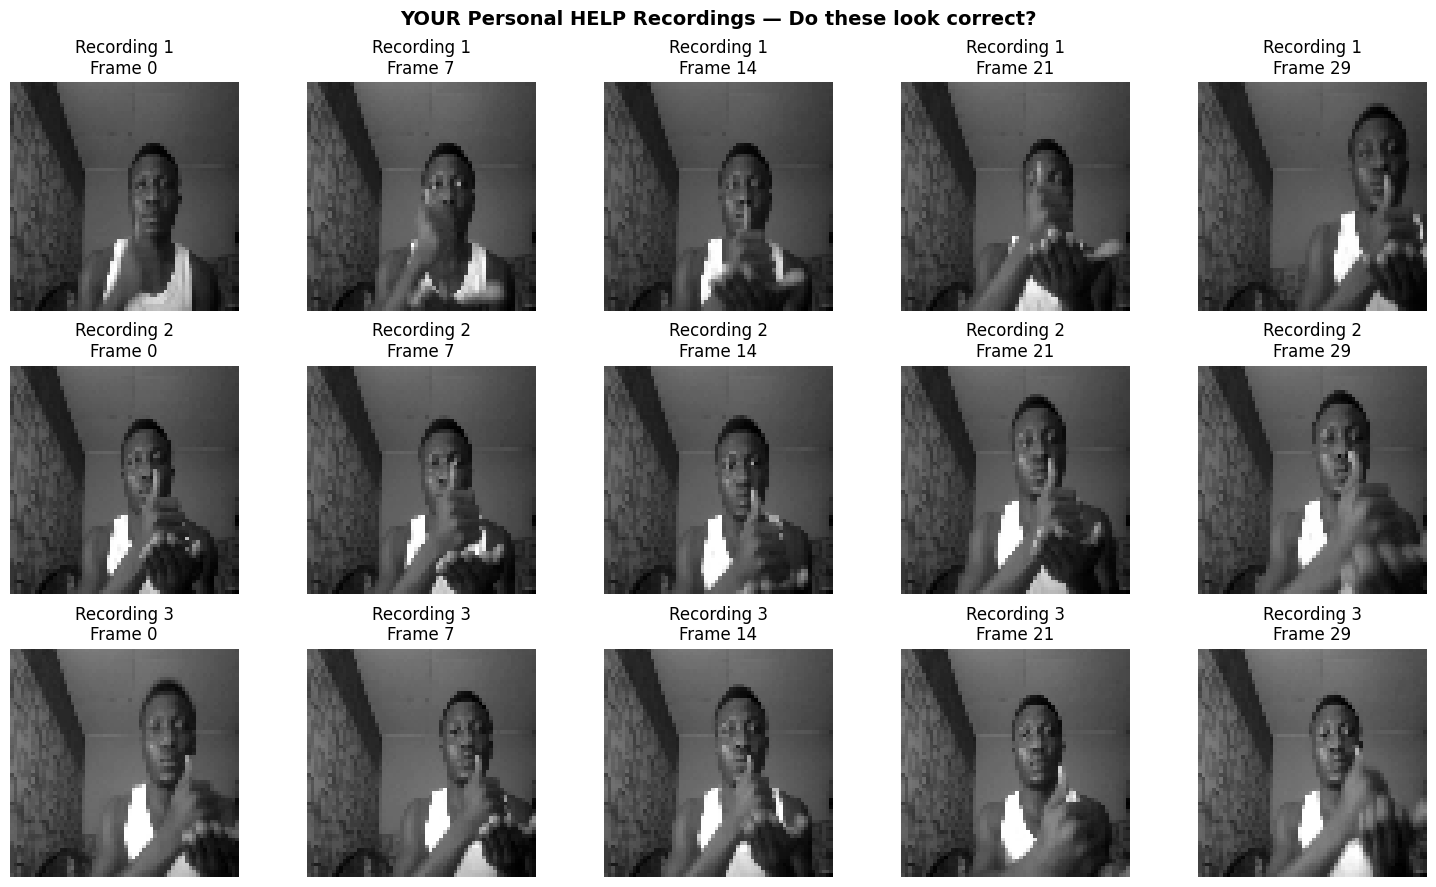

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os

SAVE_PATH = "MP_Data"

# Look at your personal help recordings specifically
help_path = os.path.join(SAVE_PATH, 'help')
all_files = os.listdir(help_path)

# Find personal recordings (saved as personal_X.npy)
personal_files = [f for f in all_files if f.startswith('personal_')]
print(f"Personal help recordings found: {len(personal_files)}")

# Show frames from first 3 personal recordings
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for row, fname in enumerate(personal_files[:3]):
    seq = np.load(os.path.join(help_path, fname))
    # Show frames 0, 7, 14, 21, 29
    for col, frame_idx in enumerate([0, 7, 14, 21, 29]):
        axes[row, col].imshow(
            seq[frame_idx].reshape(64, 64), 
            cmap='gray'
        )
        axes[row, col].set_title(f"Recording {row+1}\nFrame {frame_idx}")
        axes[row, col].axis('off')

plt.suptitle("YOUR Personal HELP Recordings — Do these look correct?", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Check how many frames per gesture and look for imbalance
import numpy as np
import os

SAVE_PATH = "MP_Data"
SELECTED_GESTURES = ['drink', 'go', 'help', 'yes', 'no']

print("📊 Data Distribution Analysis:")
print("-" * 50)

total_personal = 0
total_wlasl    = 0

for gesture in SELECTED_GESTURES:
    path     = os.path.join(SAVE_PATH, gesture)
    files    = os.listdir(path)
    
    personal = [f for f in files if f.startswith('personal_')]
    wlasl    = [f for f in files if not f.startswith('personal_')]
    
    total_personal += len(personal)
    total_wlasl    += len(wlasl)
    
    print(f"{gesture:10s} → WLASL: {len(wlasl):3d} | Personal: {len(personal):3d} | Total: {len(files):3d}")

print("-" * 50)
print(f"{'TOTAL':10s} → WLASL: {total_wlasl:3d} | Personal: {total_personal:3d}")

# Now check what the model predicts for a BLANK frame (no hand)
print("\n🔍 Testing model on BLANK frame (no gesture):")
blank_sequence = [np.zeros((64, 64, 1)) for _ in range(30)]
seq_rgb        = np.repeat(np.array(blank_sequence), 3, axis=-1)
predictions    = model.predict(seq_rgb, verbose=0)
avg_pred       = np.sum(predictions, axis=0)

print("\nProbabilities for blank frame:")
for i, gesture in enumerate(le.classes_):
    print(f"  {str(gesture):10s} → {avg_pred[i]/np.sum(avg_pred)*100:.1f}%")

📊 Data Distribution Analysis:
--------------------------------------------------
drink      → WLASL:  15 | Personal:  10 | Total:  25
go         → WLASL:  15 | Personal:  10 | Total:  25
help       → WLASL:  14 | Personal:  10 | Total:  24
yes        → WLASL:  12 | Personal:  10 | Total:  22
no         → WLASL:  11 | Personal:  10 | Total:  21
--------------------------------------------------
TOTAL      → WLASL:  67 | Personal:  50

🔍 Testing model on BLANK frame (no gesture):

Probabilities for blank frame:
  drink      → 18.0%
  go         → 22.0%
  help       → 18.2%
  no         → 20.0%
  yes        → 21.8%


📸 Capturing 5 frames from your webcam...
Hold your HELP gesture!
  Frame 1 captured ✅
  Frame 2 captured ✅
  Frame 3 captured ✅
  Frame 4 captured ✅
  Frame 5 captured ✅
Personal files found: ['personal_14.npy', 'personal_15.npy', 'personal_16.npy', 'personal_17.npy', 'personal_18.npy', 'personal_19.npy', 'personal_20.npy', 'personal_21.npy', 'personal_22.npy', 'personal_23.npy']


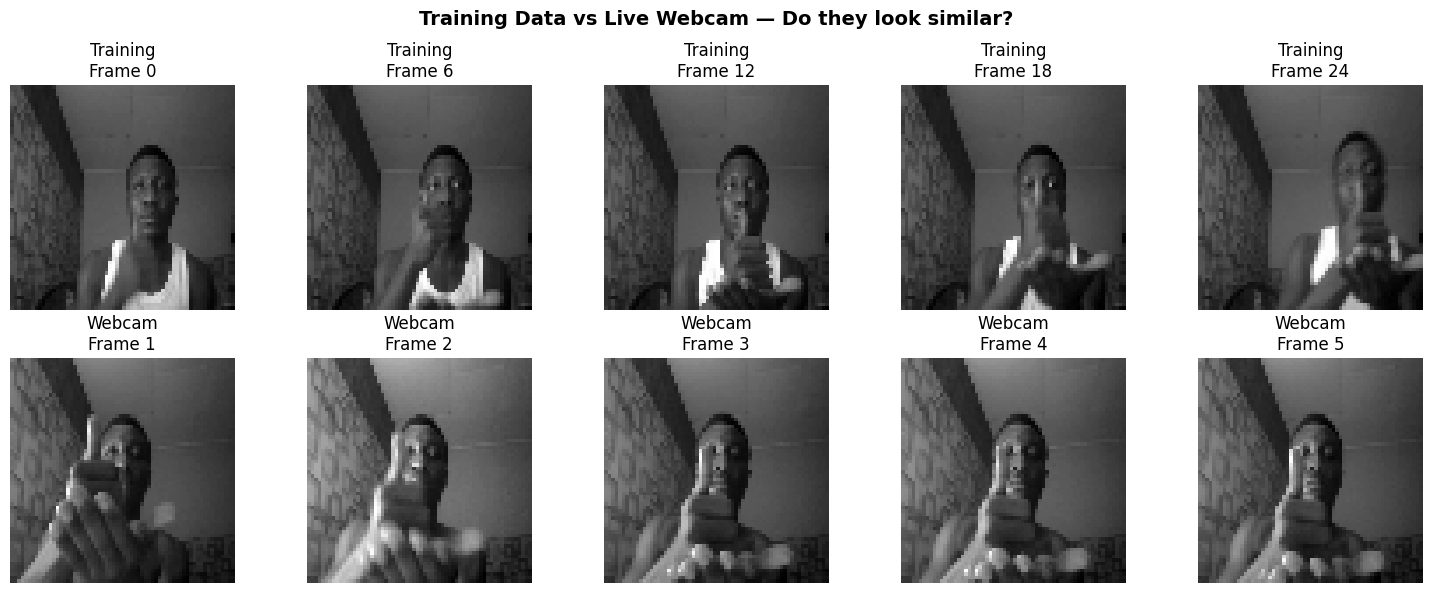


📊 Pixel Statistics Comparison:
  Training frames → Min: 0.098 | Max: 0.992 | Mean: 0.345
  Webcam frames   → Min: 0.067 | Max: 0.902 | Mean: 0.322


In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Capture one real frame from webcam and compare to training data
cap = cv2.VideoCapture(0)

print("📸 Capturing 5 frames from your webcam...")
print("Hold your HELP gesture!")

webcam_frames = []
for i in range(5):
    for _ in range(10):  # Skip frames to let camera adjust
        cap.read()
    ret, frame = cap.read()
    if ret:
        # Preprocess exactly like training
        gray       = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        resized    = cv2.resize(gray, (64, 64))
        normalized = resized / 255.0
        webcam_frames.append(normalized)
        print(f"  Frame {i+1} captured ✅")

cap.release()

# Load a training help frame for comparison
help_path  = os.path.join(SAVE_PATH, 'help')
train_file = os.path.join(help_path, 'personal_0.npy')
# Find the actual personal file name
help_path    = os.path.join(SAVE_PATH, 'help')
all_files    = os.listdir(help_path)
personal_files = [f for f in all_files if f.startswith('personal_')]
print(f"Personal files found: {personal_files}")

# Use the first one found
train_file = os.path.join(help_path, personal_files[0])
train_seq  = np.load(train_file)

# Plot comparison
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Row 1 — Training frames
for i in range(5):
    axes[0, i].imshow(train_seq[i*6].reshape(64, 64), cmap='gray')
    axes[0, i].set_title(f"Training\nFrame {i*6}")
    axes[0, i].axis('off')

# Row 2 — Live webcam frames
for i in range(5):
    axes[1, i].imshow(webcam_frames[i], cmap='gray')
    axes[1, i].set_title(f"Webcam\nFrame {i+1}")
    axes[1, i].axis('off')

plt.suptitle("Training Data vs Live Webcam — Do they look similar?",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Check pixel statistics
print("\n📊 Pixel Statistics Comparison:")
print(f"  Training frames → Min: {train_seq[:5].min():.3f} | Max: {train_seq[:5].max():.3f} | Mean: {train_seq[:5].mean():.3f}")
webcam_arr = np.array(webcam_frames)
print(f"  Webcam frames   → Min: {webcam_arr.min():.3f} | Max: {webcam_arr.max():.3f} | Mean: {webcam_arr.mean():.3f}")

In [22]:
# Check predictions on YOUR personal recordings one by one
print("🔍 Testing model on each personal recording:\n")
print(f"{'File':20s} {'True':8s} {'Predicted':10s} {'Confidence':10s} {'Correct?'}")
print("-" * 65)

correct = 0
total   = 0

for gesture in SELECTED_GESTURES:
    gesture_path   = os.path.join(SAVE_PATH, gesture)
    personal_files = [f for f in os.listdir(gesture_path) 
                      if f.startswith('personal_')]
    
    for fname in personal_files:
        seq     = np.load(os.path.join(gesture_path, fname))
        seq_rgb = np.repeat(seq, 3, axis=-1)
        
        preds      = model.predict(seq_rgb, verbose=0)
        avg_pred   = np.sum(preds, axis=0)
        class_idx  = np.argmax(avg_pred)
        confidence = float(avg_pred[class_idx] / np.sum(avg_pred)) * 100
        predicted  = str(le.classes_[class_idx])
        is_correct = "✅" if predicted == gesture else "❌"
        
        if predicted == gesture:
            correct += 1
        total += 1
        
        print(f"{fname:20s} {gesture:8s} {predicted:10s} {confidence:6.1f}%     {is_correct}")

print("-" * 65)
print(f"\n🏆 Personal recording accuracy: {correct}/{total} = {correct/total*100:.1f}%")

🔍 Testing model on each personal recording:

File                 True     Predicted  Confidence Correct?
-----------------------------------------------------------------
personal_15.npy      drink    drink        94.1%     ✅
personal_16.npy      drink    drink       100.0%     ✅
personal_17.npy      drink    drink        99.9%     ✅
personal_18.npy      drink    drink       100.0%     ✅
personal_19.npy      drink    drink       100.0%     ✅
personal_20.npy      drink    drink       100.0%     ✅
personal_21.npy      drink    drink       100.0%     ✅
personal_22.npy      drink    drink       100.0%     ✅
personal_23.npy      drink    drink       100.0%     ✅
personal_24.npy      drink    drink       100.0%     ✅
personal_15.npy      go       go           98.9%     ✅
personal_16.npy      go       go           99.2%     ✅
personal_17.npy      go       go           99.7%     ✅
personal_18.npy      go       go           99.7%     ✅
personal_19.npy      go       go           99.9%     ✅
per

In [23]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import pickle
import time

model = load_model('best_model_v2.keras')
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

IMG_SIZE        = 64
SEQUENCE_LENGTH = 30
cap             = cv2.VideoCapture(0)

print("🎥 SignSpeak Live Test")
print("=" * 40)
print("Instructions:")
print("1. Get your hand ready BEFORE countdown")
print("2. Hold gesture STILL during capture")
print("3. Press Q to quit")
print("=" * 40)

while True:
    # ── STEP 1: Show preview with countdown ──────────────────
    print("\n⏳ Get ready... showing preview for 3 seconds")
    
    start_time = time.time()
    while time.time() - start_time < 3:
        ret, frame = cap.read()
        if not ret:
            break
        remaining = 3 - int(time.time() - start_time)
        display   = frame.copy()
        
        cv2.putText(display, f"GET READY: {remaining}s",
                   (30, 60), cv2.FONT_HERSHEY_SIMPLEX,
                   1.5, (0, 255, 255), 3)
        cv2.putText(display, "Hold your gesture steady!",
                   (30, 120), cv2.FONT_HERSHEY_SIMPLEX,
                   0.8, (255, 255, 255), 2)
        cv2.imshow('SignSpeak Live', display)
        
        key = cv2.waitKey(1)
        if key == ord('q'):
            cap.release()
            cv2.destroyAllWindows()
            print("Quit!")
            break

    # ── STEP 2: Capture 30 frames ─────────────────────────────
    print("🔴 Capturing now — HOLD YOUR GESTURE!")
    sequence = []

    for i in range(SEQUENCE_LENGTH):
        ret, frame = cap.read()
        if not ret:
            break

        display = frame.copy()
        cv2.putText(display, f"RECORDING {i+1}/30",
                   (30, 60), cv2.FONT_HERSHEY_SIMPLEX,
                   1.5, (0, 0, 255), 3)
        cv2.imshow('SignSpeak Live', display)
        cv2.waitKey(100)
        # 💡 100ms between frames = 3 seconds total
        #    Same timing as during recording!

        # Preprocess exactly like training
        gray       = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        resized    = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))
        normalized = resized / 255.0
        sequence.append(normalized.reshape(IMG_SIZE, IMG_SIZE, 1))

    # ── STEP 3: Predict ───────────────────────────────────────
    seq_rgb    = np.repeat(np.array(sequence), 3, axis=-1)
    preds      = model.predict(seq_rgb, verbose=0)
    avg_pred   = np.sum(preds, axis=0)
    class_idx  = np.argmax(avg_pred)
    confidence = float(avg_pred[class_idx] / np.sum(avg_pred)) * 100
    gesture    = str(le.classes_[class_idx])

    print(f"\n✋ Result: {gesture.upper()} ({confidence:.1f}%)")
    print("\nProbabilities:")
    for i, g in enumerate(le.classes_):
        bar = "█" * int(avg_pred[i]/np.sum(avg_pred)*20)
        print(f"  {str(g):8s} {bar:20s} {avg_pred[i]/np.sum(avg_pred)*100:.1f}%")

    # ── STEP 4: Show result ───────────────────────────────────
    ret, frame = cap.read()
    if ret:
        color = (0, 255, 0) if confidence > 70 else (0, 165, 255)
        cv2.putText(frame, f"{gesture.upper()}",
                   (30, 80), cv2.FONT_HERSHEY_SIMPLEX,
                   3, color, 4)
        cv2.putText(frame, f"Confidence: {confidence:.1f}%",
                   (30, 140), cv2.FONT_HERSHEY_SIMPLEX,
                   1, color, 2)
        cv2.imshow('SignSpeak Live', frame)
        cv2.waitKey(2000)
        # 💡 Show result for 2 seconds

    key = cv2.waitKey(1)
    if key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("\n✅ Done!")

🎥 SignSpeak Live Test
Instructions:
1. Get your hand ready BEFORE countdown
2. Hold gesture STILL during capture
3. Press Q to quit

⏳ Get ready... showing preview for 3 seconds
🔴 Capturing now — HOLD YOUR GESTURE!

✋ Result: HELP (99.9%)

Probabilities:
  drink                         0.0%
  go                            0.1%
  help     ███████████████████  99.9%
  no                            0.0%
  yes                           0.0%

⏳ Get ready... showing preview for 3 seconds
🔴 Capturing now — HOLD YOUR GESTURE!

✋ Result: HELP (100.0%)

Probabilities:
  drink                         0.0%
  go                            0.0%
  help     ███████████████████  100.0%
  no                            0.0%
  yes                           0.0%

⏳ Get ready... showing preview for 3 seconds
🔴 Capturing now — HOLD YOUR GESTURE!

✋ Result: HELP (99.9%)

Probabilities:
  drink                         0.0%
  go                            0.1%
  help     ███████████████████  99.9%
  no         

C:\Users\lenovo\Desktop\SignSpeak\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


UnboundLocalError: cannot access local variable 'batch_outputs' where it is not associated with a value

In [24]:
import os

SAVE_PATH         = "MP_Data"
SELECTED_GESTURES = ['drink', 'go', 'help', 'yes', 'no']

print("🗑️ Deleting all personal recordings...")

for gesture in SELECTED_GESTURES:
    gesture_path   = os.path.join(SAVE_PATH, gesture)
    personal_files = [f for f in os.listdir(gesture_path) 
                      if f.startswith('personal_')]
    
    for f in personal_files:
        os.remove(os.path.join(gesture_path, f))
    
    print(f"  ✅ {gesture:10s} → {len(personal_files)} personal files deleted")

print("\n✅ All personal recordings deleted!")

🗑️ Deleting all personal recordings...
  ✅ drink      → 10 personal files deleted
  ✅ go         → 10 personal files deleted
  ✅ help       → 10 personal files deleted
  ✅ yes        → 10 personal files deleted
  ✅ no         → 10 personal files deleted

✅ All personal recordings deleted!


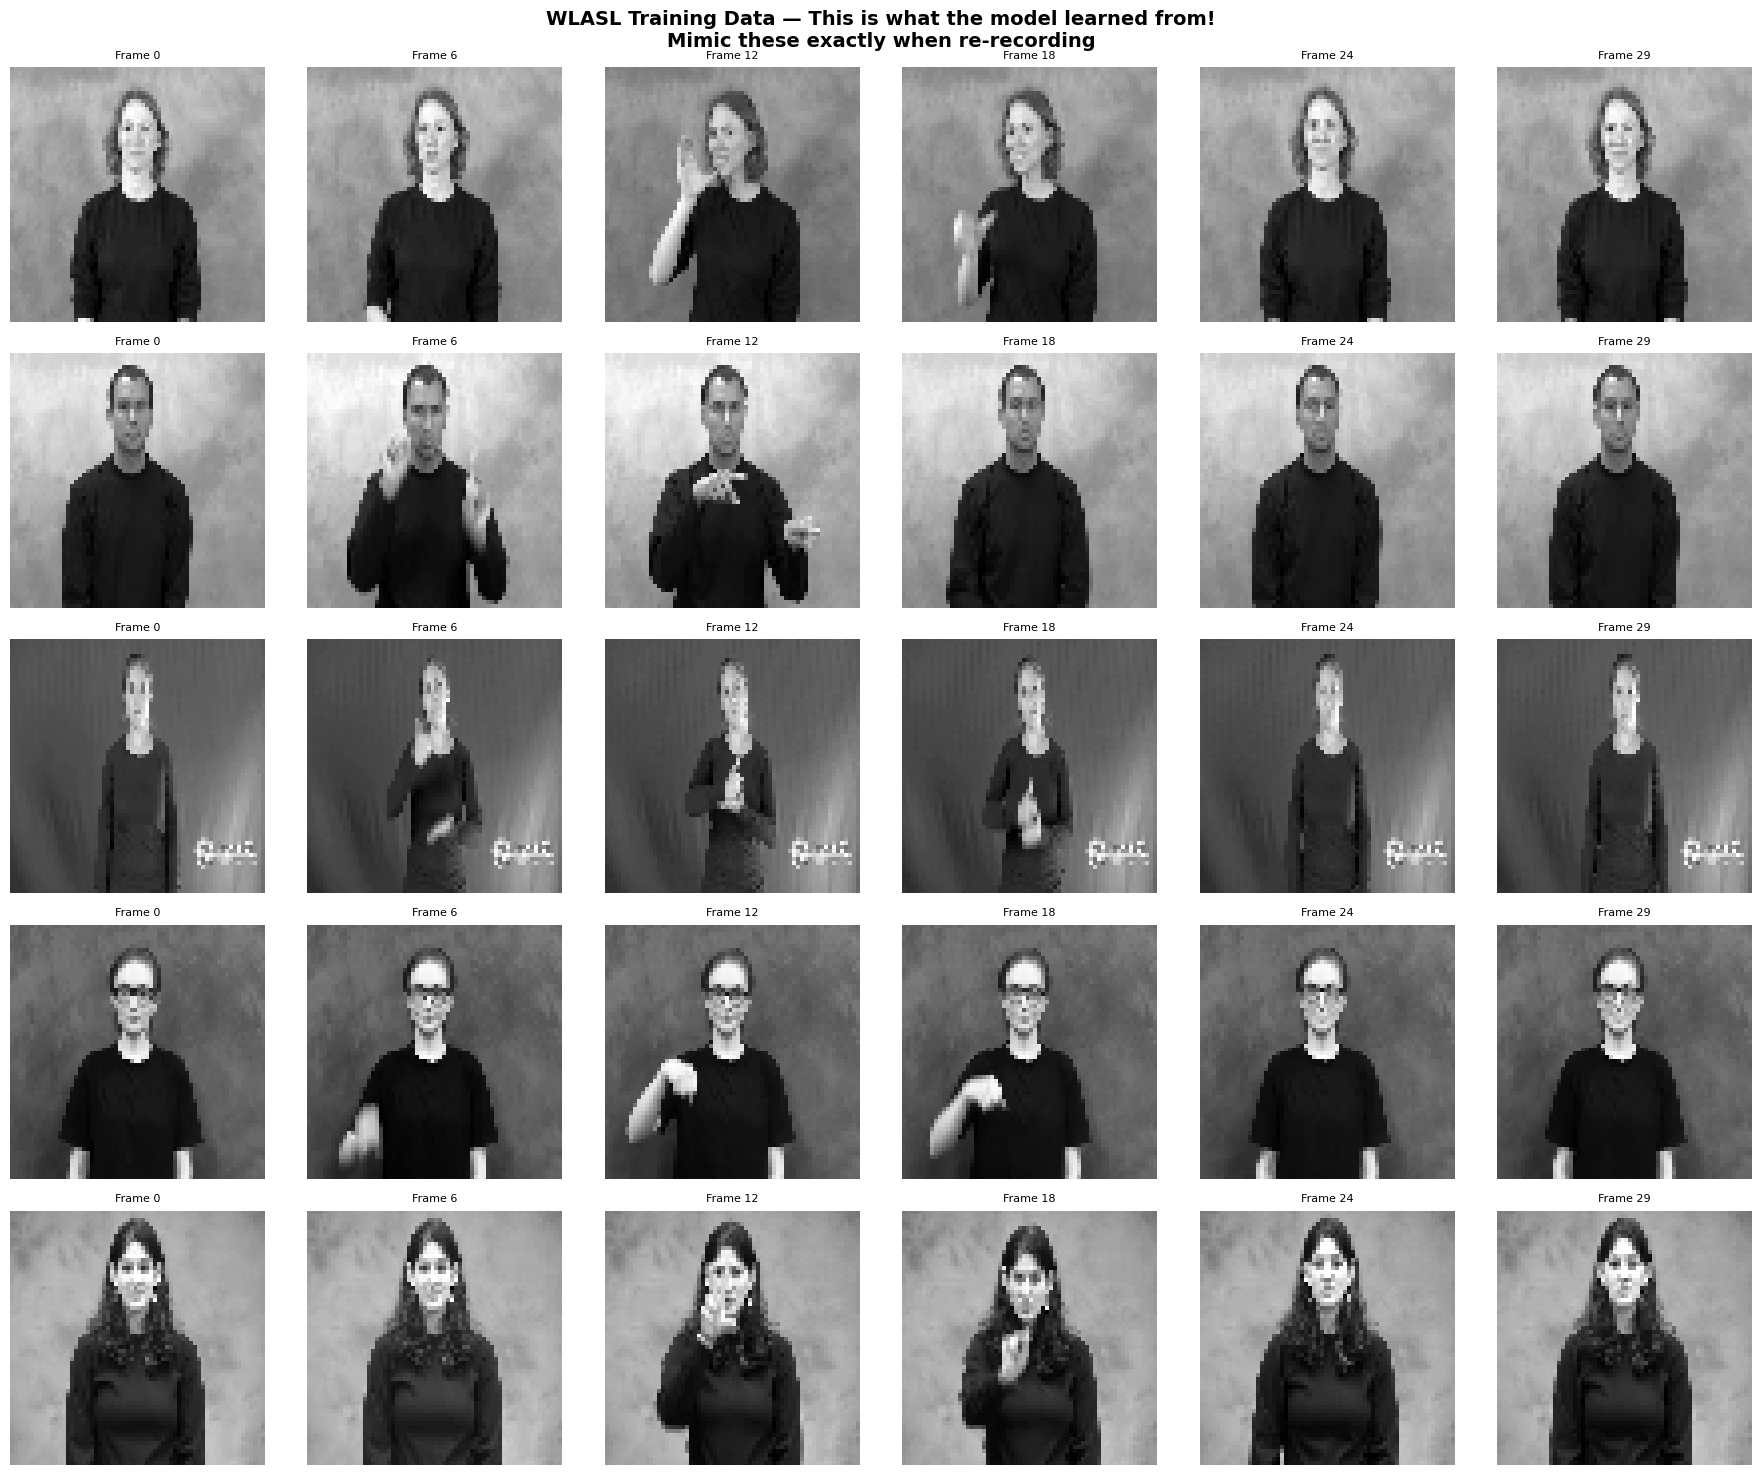

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import os

SAVE_PATH         = "MP_Data"
SELECTED_GESTURES = ['drink', 'go', 'help', 'yes', 'no']

fig, axes = plt.subplots(5, 6, figsize=(18, 15))

for row, gesture in enumerate(SELECTED_GESTURES):
    gesture_path = os.path.join(SAVE_PATH, gesture)
    
    # Load first WLASL file (not personal)
    wlasl_files = [f for f in os.listdir(gesture_path) 
                   if not f.startswith('personal_')]
    
    seq = np.load(os.path.join(gesture_path, wlasl_files[0]))
    
    # Show 6 evenly spaced frames
    frame_indices = [0, 6, 12, 18, 24, 29]
    for col, idx in enumerate(frame_indices):
        axes[row, col].imshow(seq[idx].reshape(64, 64), cmap='gray')
        axes[row, col].set_title(f"Frame {idx}", fontsize=8)
        axes[row, col].axis('off')
    
    axes[row, 0].set_ylabel(gesture.upper(), fontsize=14, 
                             fontweight='bold', rotation=0, 
                             labelpad=60, color='purple')

plt.suptitle("WLASL Training Data — This is what the model learned from!\nMimic these exactly when re-recording", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
import cv2
import numpy as np
import os

GESTURES_TO_RECORD = ['drink', 'go', 'help', 'yes', 'no']
VIDEOS_PER_GESTURE = 20   # Increased from 10 to 20!
SAVE_PATH          = "MP_Data"

cap = cv2.VideoCapture(0)

print("📹 Personal Data Collection — CORRECTED VERSION")
print("=" * 45)
print("Instructions:")
print("1. Camera is now correctly flipped!")
print("2. Get ready DURING the countdown")
print("3. Hold gesture STILL during recording")
print("4. Make gesture BIG and CLEAR")
print("=" * 45)

for gesture in GESTURES_TO_RECORD:
    gesture_path = os.path.join(SAVE_PATH, gesture)
    existing     = len([f for f in os.listdir(gesture_path)
                        if f.endswith('.npy')])

    print(f"\n🤚 Gesture: {gesture.upper()}")
    input(f"   Press ENTER when ready...")

    for video_num in range(VIDEOS_PER_GESTURE):
        print(f"   Video {video_num+1}/{VIDEOS_PER_GESTURE}")

        # 3 second countdown
        for count in [3, 2, 1]:
            ret, frame = cap.read()
            frame      = cv2.flip(frame, 1)
            # 💡 Flip BEFORE showing and processing!
            #    Now what you see is what the model sees

            cv2.putText(frame, f"GET READY: {count}",
                       (30, 60), cv2.FONT_HERSHEY_SIMPLEX,
                       1.5, (0, 255, 255), 3)
            cv2.putText(frame, f"Gesture: {gesture.upper()}",
                       (30, 130), cv2.FONT_HERSHEY_SIMPLEX,
                       1.5, (255, 255, 0), 3)
            cv2.putText(frame, "Position your hand NOW!",
                       (30, 200), cv2.FONT_HERSHEY_SIMPLEX,
                       0.8, (255, 255, 255), 2)
            cv2.imshow('Recording', frame)
            cv2.waitKey(1000)

        # Record 30 frames
        sequence = []
        for frame_num in range(30):
            ret, frame = cap.read()
            frame      = cv2.flip(frame, 1)
            # 💡 Same flip during actual recording
            #    This matches the WLASL video orientation

            display = frame.copy()
            cv2.putText(display, f"RECORDING {frame_num+1}/30",
                       (30, 60), cv2.FONT_HERSHEY_SIMPLEX,
                       1.5, (0, 0, 255), 3)
            cv2.putText(display, gesture.upper(),
                       (30, 140), cv2.FONT_HERSHEY_SIMPLEX,
                       2, (0, 255, 0), 3)
            cv2.imshow('Recording', display)
            cv2.waitKey(100)

            # Preprocess exactly like training
            gray       = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            resized    = cv2.resize(gray, (64, 64))
            normalized = resized / 255.0
            sequence.append(normalized.reshape(64, 64, 1))

        # Save
        save_file = os.path.join(gesture_path,
                                 f"personal_{existing+video_num}.npy")
        np.save(save_file, np.array(sequence))
        print(f"   ✅ Saved video {video_num+1}")

cap.release()
cv2.destroyAllWindows()
print("\n✅ Personal data collection complete!")
print("Now retrain the model!")

📹 Personal Data Collection — CORRECTED VERSION
Instructions:
1. Camera is now correctly flipped!
2. Get ready DURING the countdown
3. Hold gesture STILL during recording
4. Make gesture BIG and CLEAR

🤚 Gesture: DRINK


   Press ENTER when ready... 


   Video 1/20
   ✅ Saved video 1
   Video 2/20
   ✅ Saved video 2
   Video 3/20
   ✅ Saved video 3
   Video 4/20
   ✅ Saved video 4
   Video 5/20
   ✅ Saved video 5
   Video 6/20
   ✅ Saved video 6
   Video 7/20
   ✅ Saved video 7
   Video 8/20
   ✅ Saved video 8
   Video 9/20
   ✅ Saved video 9
   Video 10/20
   ✅ Saved video 10
   Video 11/20
   ✅ Saved video 11
   Video 12/20
   ✅ Saved video 12
   Video 13/20
   ✅ Saved video 13
   Video 14/20
   ✅ Saved video 14
   Video 15/20
   ✅ Saved video 15
   Video 16/20
   ✅ Saved video 16
   Video 17/20
   ✅ Saved video 17
   Video 18/20
   ✅ Saved video 18
   Video 19/20
   ✅ Saved video 19
   Video 20/20
   ✅ Saved video 20

🤚 Gesture: GO


   Press ENTER when ready... 


   Video 1/20
   ✅ Saved video 1
   Video 2/20
   ✅ Saved video 2
   Video 3/20
   ✅ Saved video 3
   Video 4/20
   ✅ Saved video 4
   Video 5/20
   ✅ Saved video 5
   Video 6/20
   ✅ Saved video 6
   Video 7/20
   ✅ Saved video 7
   Video 8/20
   ✅ Saved video 8
   Video 9/20
   ✅ Saved video 9
   Video 10/20
   ✅ Saved video 10
   Video 11/20
   ✅ Saved video 11
   Video 12/20
   ✅ Saved video 12
   Video 13/20
   ✅ Saved video 13
   Video 14/20
   ✅ Saved video 14
   Video 15/20
   ✅ Saved video 15
   Video 16/20
   ✅ Saved video 16
   Video 17/20
   ✅ Saved video 17
   Video 18/20
   ✅ Saved video 18
   Video 19/20
   ✅ Saved video 19
   Video 20/20
   ✅ Saved video 20

🤚 Gesture: HELP


...

   Video 1/20
   ✅ Saved video 1
   Video 2/20
   ✅ Saved video 2
   Video 3/20
   ✅ Saved video 3
   Video 4/20
   ✅ Saved video 4
   Video 5/20
   ✅ Saved video 5
   Video 6/20
   ✅ Saved video 6
   Video 7/20
   ✅ Saved video 7
   Video 8/20
   ✅ Saved video 8
   Video 9/20
   ✅ Saved video 9
   Video 10/20
   ✅ Saved video 10
   Video 11/20
   ✅ Saved video 11
   Video 12/20
   ✅ Saved video 12
   Video 13/20
   ✅ Saved video 13
   Video 14/20
   ✅ Saved video 14
   Video 15/20
   ✅ Saved video 15
   Video 16/20
   ✅ Saved video 16
   Video 17/20
   ✅ Saved video 17
   Video 18/20
   ✅ Saved video 18
   Video 19/20
   ✅ Saved video 19
   Video 20/20
   ✅ Saved video 20

🤚 Gesture: YES


   Press ENTER when ready... 


   Video 1/20
   ✅ Saved video 1
   Video 2/20
   ✅ Saved video 2
   Video 3/20
   ✅ Saved video 3
   Video 4/20
   ✅ Saved video 4
   Video 5/20
   ✅ Saved video 5
   Video 6/20
   ✅ Saved video 6
   Video 7/20
   ✅ Saved video 7
   Video 8/20
   ✅ Saved video 8
   Video 9/20
   ✅ Saved video 9
   Video 10/20
   ✅ Saved video 10
   Video 11/20
   ✅ Saved video 11
   Video 12/20
   ✅ Saved video 12
   Video 13/20
   ✅ Saved video 13
   Video 14/20
   ✅ Saved video 14
   Video 15/20
   ✅ Saved video 15
   Video 16/20
   ✅ Saved video 16
   Video 17/20
   ✅ Saved video 17
   Video 18/20
   ✅ Saved video 18
   Video 19/20
   ✅ Saved video 19
   Video 20/20
   ✅ Saved video 20

🤚 Gesture: NO


   Press ENTER when ready... 


   Video 1/20
   ✅ Saved video 1
   Video 2/20
   ✅ Saved video 2
   Video 3/20
   ✅ Saved video 3
   Video 4/20
   ✅ Saved video 4
   Video 5/20
   ✅ Saved video 5
   Video 6/20
   ✅ Saved video 6
   Video 7/20
   ✅ Saved video 7
   Video 8/20
   ✅ Saved video 8
   Video 9/20
   ✅ Saved video 9
   Video 10/20
   ✅ Saved video 10
   Video 11/20
   ✅ Saved video 11
   Video 12/20
   ✅ Saved video 12
   Video 13/20
   ✅ Saved video 13
   Video 14/20
   ✅ Saved video 14
   Video 15/20
   ✅ Saved video 15
   Video 16/20
   ✅ Saved video 16
   Video 17/20
   ✅ Saved video 17
   Video 18/20
   ✅ Saved video 18
   Video 19/20
   ✅ Saved video 19
   Video 20/20
   ✅ Saved video 20

✅ Personal data collection complete!
Now retrain the model!


In [26]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import pickle
import time

model = load_model('best_model_v2.keras')
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

IMG_SIZE        = 64
SEQUENCE_LENGTH = 30
cap             = cv2.VideoCapture(0)

print("🎥 SignSpeak Live Test — FLIP CORRECTED")
print("=" * 40)
print("Press Q to quit")
print("=" * 40)

while True:
    # Preview countdown
    print("\n⏳ Get ready... 3 seconds")
    start_time = time.time()
    while time.time() - start_time < 3:
        ret, frame = cap.read()
        frame      = cv2.flip(frame, 1)
        # 💡 Flip so preview matches what model expects

        remaining = 3 - int(time.time() - start_time)
        cv2.putText(frame, f"GET READY: {remaining}s",
                   (30, 60), cv2.FONT_HERSHEY_SIMPLEX,
                   1.5, (0, 255, 255), 3)
        cv2.putText(frame, "Hold your gesture!",
                   (30, 130), cv2.FONT_HERSHEY_SIMPLEX,
                   1, (255, 255, 255), 2)
        cv2.imshow('SignSpeak Live', frame)
        cv2.waitKey(1)

    # Capture 30 frames
    print("🔴 Capturing — HOLD STILL!")
    sequence = []

    for i in range(SEQUENCE_LENGTH):
        ret, frame = cap.read()
        frame      = cv2.flip(frame, 1)
        # 💡 Flip during capture too!

        display = frame.copy()
        cv2.putText(display, f"RECORDING {i+1}/30",
                   (30, 60), cv2.FONT_HERSHEY_SIMPLEX,
                   1.5, (0, 0, 255), 3)
        cv2.imshow('SignSpeak Live', display)
        cv2.waitKey(100)

        gray       = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        resized    = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))
        normalized = resized / 255.0
        sequence.append(normalized.reshape(IMG_SIZE, IMG_SIZE, 1))

    # Predict
    seq_rgb    = np.repeat(np.array(sequence), 3, axis=-1)
    preds      = model.predict(seq_rgb, verbose=0)
    avg_pred   = np.sum(preds, axis=0)
    class_idx  = np.argmax(avg_pred)
    confidence = float(avg_pred[class_idx] / np.sum(avg_pred)) * 100
    gesture    = str(le.classes_[class_idx])

    print(f"\n✋ Result: {gesture.upper()} ({confidence:.1f}%)")
    print("Probabilities:")
    for i, g in enumerate(le.classes_):
        bar = "█" * int(avg_pred[i]/np.sum(avg_pred)*20)
        print(f"  {str(g):8s} {bar:20s} {avg_pred[i]/np.sum(avg_pred)*100:.1f}%")

    # Show result
    ret, frame = cap.read()
    frame      = cv2.flip(frame, 1)
    color      = (0, 255, 0) if confidence > 70 else (0, 165, 255)
    cv2.putText(frame, f"{gesture.upper()} ({confidence:.1f}%)",
               (30, 80), cv2.FONT_HERSHEY_SIMPLEX,
               1.5, color, 3)
    cv2.imshow('SignSpeak Live', frame)

    key = cv2.waitKey(2000)
    if key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("✅ Done!")

🎥 SignSpeak Live Test — FLIP CORRECTED
Press Q to quit

⏳ Get ready... 3 seconds
🔴 Capturing — HOLD STILL!

✋ Result: GO (63.3%)
Probabilities:
  drink    █                    8.7%
  go       ████████████         63.3%
  help     █                    5.9%
  no       ████                 21.3%
  yes                           0.9%

⏳ Get ready... 3 seconds
🔴 Capturing — HOLD STILL!

✋ Result: HELP (91.8%)
Probabilities:
  drink                         0.2%
  go                            0.6%
  help     ██████████████████   91.8%
  no       █                    7.3%
  yes                           0.2%

⏳ Get ready... 3 seconds
🔴 Capturing — HOLD STILL!

✋ Result: HELP (60.9%)
Probabilities:
  drink                         1.2%
  go       ██████               34.0%
  help     ████████████         60.9%
  no                            2.9%
  yes                           0.9%

⏳ Get ready... 3 seconds
🔴 Capturing — HOLD STILL!

✋ Result: GO (46.9%)
Probabilities:
  drink                  